In [1]:
import geopandas as gpd
import json
import os

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"

# ── Inspect one ancient file
ancient = gpd.read_file(os.path.join(BASEMAP_PATH, "world_bc2000.geojson"))
print("=== 2000 BCE SNAPSHOT ===")
print(f"Total features: {len(ancient)}")
print(f"Columns: {ancient.columns.tolist()}")
print(f"\nAll territory names:")
for col in ancient.columns:
    if col != 'geometry':
        print(f"\n  Column '{col}':")
        print(ancient[col].dropna().unique()[:30])

# ── Inspect one medieval file
medieval = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1200.geojson"))
print("\n\n=== 1200 CE SNAPSHOT ===")
print(f"Total features: {len(medieval)}")
print(f"\nAll territory names:")
for col in medieval.columns:
    if col != 'geometry':
        print(f"\n  Column '{col}':")
        print(medieval[col].dropna().unique()[:30])

# ── Inspect one modern file
modern = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1880.geojson"))
print("\n\n=== 1880 CE SNAPSHOT ===")
print(f"Total features: {len(modern)}")
print(f"\nAll territory names:")
for col in modern.columns:
    if col != 'geometry':
        print(f"\n  Column '{col}':")
        print(modern[col].dropna().unique()[:30])

=== 2000 BCE SNAPSHOT ===
Total features: 145
Columns: ['NAME', 'ABBREVN', 'type', 'weblnks', 'SUBJECTO', 'BORDERPRECISION', 'PARTOF', 'geometry']

All territory names:

  Column 'NAME':
<ArrowStringArray>
[                               'Dakapeng culture',
                                   'Austronesians',
                                           'Jōmon',
                                     'Norte Chico',
                                     'city-states',
                                              'Ur',
                                            'Elam',
                                          'Canaan',
                                         'Khoisan',
                                           'Egypt',
                       'Indus valley civilization',
                                'Hurrian Kingdoms',
                                        'Valdivia',
                                           'Kerma',
                                         'Semites',
              

In [2]:
import geopandas as gpd
import os
import pandas as pd

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"

# Load every snapshot and collect all unique names
all_names = {}
snapshot_files = sorted([
    f for f in os.listdir(BASEMAP_PATH)
    if f.startswith('world_') and f.endswith('.geojson')
])

print(f"Total snapshot files: {len(snapshot_files)}")
print(f"Files: {snapshot_files}\n")

name_records = []
for fname in snapshot_files:
    year_str = fname.replace('world_', '').replace('.geojson', '')
    # Convert to integer year
    if year_str.startswith('bc'):
        year = -int(year_str.replace('bc', ''))
    else:
        try:
            year = int(year_str)
        except:
            continue

    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    names = gdf['NAME'].dropna().unique().tolist()
    for n in names:
        name_records.append({'year': year, 'name': n})

df_names = pd.DataFrame(name_records)

# All unique territory names across all time
all_unique = sorted(df_names['name'].unique().tolist())
print(f"Total unique territory names across all snapshots: {len(all_unique)}")
print("\n=== ALL UNIQUE NAMES ===")
for n in all_unique:
    print(f"  {n}")

Total snapshot files: 53
Files: ['world_100.geojson', 'world_1000.geojson', 'world_1100.geojson', 'world_1200.geojson', 'world_1279.geojson', 'world_1300.geojson', 'world_1400.geojson', 'world_1492.geojson', 'world_1500.geojson', 'world_1530.geojson', 'world_1600.geojson', 'world_1650.geojson', 'world_1700.geojson', 'world_1715.geojson', 'world_1783.geojson', 'world_1800.geojson', 'world_1815.geojson', 'world_1880.geojson', 'world_1900.geojson', 'world_1914.geojson', 'world_1920.geojson', 'world_1930.geojson', 'world_1938.geojson', 'world_1945.geojson', 'world_1960.geojson', 'world_1994.geojson', 'world_200.geojson', 'world_2000.geojson', 'world_2010.geojson', 'world_300.geojson', 'world_400.geojson', 'world_500.geojson', 'world_600.geojson', 'world_700.geojson', 'world_800.geojson', 'world_900.geojson', 'world_bc1.geojson', 'world_bc100.geojson', 'world_bc1000.geojson', 'world_bc10000.geojson', 'world_bc123000.geojson', 'world_bc1500.geojson', 'world_bc200.geojson', 'world_bc2000.geoj

In [3]:
import geopandas as gpd
import os
import pandas as pd

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"

# Our civilisation roster — name + year range
our_civs = [
    # Original 45
    ("Sumerian City-States", -3000, -2004),
    ("Akkadian Empire", -2334, -2154),
    ("Neo-Babylonian Empire", -626, -539),
    ("Achaemenid Persian Empire", -550, -330),
    ("Sassanid Empire", 224, 651),
    ("Ancient Egypt - New Kingdom", -1550, -1069),
    ("Classical Greece", -800, -146),
    ("Macedonian Empire", -336, -301),
    ("Roman Empire", -27, 476),
    ("Byzantine Empire", 330, 1453),
    ("Parthian Empire", -247, 224),
    ("Umayyad Caliphate", 661, 750),
    ("Abbasid Caliphate", 750, 1258),
    ("Ottoman Empire", 1299, 1922),
    ("Maurya Empire", -322, -185),
    ("Gupta Empire", 320, 550),
    ("Mughal Empire", 1526, 1857),
    ("Qin Dynasty", -221, -206),
    ("Han Dynasty", -206, 220),
    ("Tang Dynasty", 618, 907),
    ("Song Dynasty", 960, 1279),
    ("Yuan Dynasty", 1271, 1368),
    ("Ming Dynasty", 1368, 1644),
    ("Qing Dynasty", 1644, 1912),
    ("Mongol Empire", 1206, 1368),
    ("Timurid Empire", 1370, 1507),
    ("Kingdom of Kush", -1070, 350),
    ("Kingdom of Aksum", 100, 940),
    ("Mali Empire", 1235, 1670),
    ("Classic Maya", 250, 900),
    ("Teotihuacan", -100, 750),
    ("Aztec Empire", 1345, 1521),
    ("Inca Empire", 1438, 1533),
    ("Carolingian Empire", 800, 888),
    ("Holy Roman Empire", 962, 1806),
    ("Spanish Empire", 1492, 1898),
    ("Napoleonic Empire", 1804, 1815),
    ("Austro-Hungarian Empire", 1867, 1918),
    ("German Empire and Third Reich", 1871, 1945),
    ("Italian Colonial Empire", 1882, 1947),
    ("Empire of Japan", 1868, 1947),
    ("French Colonial Empire", 1534, 1980),
    ("British Empire", 1583, 1997),
    ("Russian Empire and USSR", 1547, 1991),
    ("Portuguese Empire", 1415, 1999),
    # Tier 1 additions
    ("Hittite Empire", -1650, -1180),
    ("Mycenaean Greece", -1600, -1100),
    ("Carthage", -814, -146),
    ("Seleucid Empire", -312, -63),
    ("Lydian Kingdom", -1200, -547),
    ("Shang Dynasty", -1600, -1046),
    ("Zhou Dynasty", -1046, -256),
    ("Sui Dynasty", 581, 618),
    ("Khmer Empire", 802, 1431),
    ("Srivijaya Empire", 650, 1275),
    ("Vijayanagara Empire", 1336, 1646),
    ("Songhai Empire", 1464, 1591),
    ("Great Zimbabwe", 1100, 1450),
    ("Xiongnu Confederation", -209, 93),
    ("Golden Horde", 1242, 1502),
    ("Kievan Rus", 882, 1240),
    ("Kingdom of France", 987, 1792),
    ("Republic of Venice", 697, 1797),
    # South Asia additions
    ("Indus Valley Civilisation", -2600, -1900),
    ("Kushan Empire", 30, 375),
    ("Chola Dynasty", 848, 1279),
    ("Delhi Sultanate", 1206, 1526),
    ("Maratha Empire", 1674, 1818),
    # Africa additions
    ("Ghana Empire", 700, 1240),
    ("Kanem-Bornu Empire", 700, 1900),
    ("Kingdom of Kongo", 1390, 1914),
    ("Mutapa Empire", 1430, 1760),
    ("Ethiopian Empire", 1270, 1974),
    ("Sokoto Caliphate", 1804, 1903),
    ("Kingdom of Benin", 1180, 1897),
    ("Kilwa Sultanate", 900, 1513),
    ("Asante Empire", 1701, 1902),
]

# Candidate repo names for matching — built from the full name list
# We try multiple variants for robustness
repo_candidates = {
    "Sumerian City-States":          ["city-states", "Ur"],
    "Akkadian Empire":               ["Akkad"],
    "Neo-Babylonian Empire":         ["Babylonia"],
    "Achaemenid Persian Empire":     ["Achaemenid Empire"],
    "Sassanid Empire":               ["Sasanian Empire", "Sasanian dependencies"],
    "Ancient Egypt - New Kingdom":   ["Egypt"],
    "Classical Greece":              ["Greek city-states", "Greece"],
    "Macedonian Empire":             ["Empire of Alexander", "Macedon and Hellenic League"],
    "Roman Empire":                  ["Roman Empire", "Rome", "Western Roman Empire", "Eastern Roman Empire"],
    "Byzantine Empire":              ["Byzantine Empire"],
    "Parthian Empire":               ["Parthian Empire", "Parthia"],
    "Umayyad Caliphate":             ["Umayyad Caliphate"],
    "Abbasid Caliphate":             ["Abbasid Caliphate"],
    "Ottoman Empire":                ["Ottoman Empire", "Ottoman Sultanate"],
    "Maurya Empire":                 ["Mauryan Empire"],
    "Gupta Empire":                  ["Gupta Empire"],
    "Mughal Empire":                 ["Mughal Empire"],
    "Qin Dynasty":                   ["Qin"],
    "Han Dynasty":                   ["Han", "Han Empire"],
    "Tang Dynasty":                  ["Tang Empire"],
    "Song Dynasty":                  ["Song Empire"],
    "Yuan Dynasty":                  ["China", "Mongol Empire"],
    "Ming Dynasty":                  ["Ming Chinese Empire", "Ming Empire"],
    "Qing Dynasty":                  ["Qing Empire", "Manchu Empire"],
    "Mongol Empire":                 ["Mongol Empire"],
    "Timurid Empire":                ["Timurid Empire", "Timurid Emirates"],
    "Kingdom of Kush":               ["Kush", "Kushites", "Meroe"],
    "Kingdom of Aksum":              ["Axum"],
    "Mali Empire":                   ["Mali"],
    "Classic Maya":                  ["Maya", "Maya city-states", "Maya chiefdoms and states"],
    "Teotihuacan":                   ["Teotihuacán", "Teotihuacàn"],
    "Aztec Empire":                  ["Aztec Empire", "Mexihcah (Triple Alliance)"],
    "Inca Empire":                   ["Inca Empire"],
    "Carolingian Empire":            ["Carolingian Empire", "Frankish Kingdom"],
    "Holy Roman Empire":             ["Holy Roman Empire"],
    "Spanish Empire":                ["Spain", "Vice Royalty of New Spain", "Vice-Royalty of Peru"],
    "Napoleonic Empire":             ["France"],
    "Austro-Hungarian Empire":       ["Austria Hungary", "Austro-Hungarian Empire", "Austrian Empire"],
    "German Empire and Third Reich": ["German Empire", "Germany"],
    "Italian Colonial Empire":       ["Italy"],
    "Empire of Japan":               ["Empire of Japan", "Imperial Japan"],
    "French Colonial Empire":        ["France", "French Indo-China", "French West Africa"],
    "British Empire":                ["United Kingdom of Great Britain and Ireland", "British Raj"],
    "Russian Empire and USSR":       ["Russian Empire", "USSR", "Russia"],
    "Portuguese Empire":             ["Portugal"],
    "Hittite Empire":                ["Hittites"],
    "Mycenaean Greece":              ["Greek city-states"],
    "Carthage":                      ["Carthage", "Carthaginian Empire"],
    "Seleucid Empire":               ["Seleucid Kingdom"],
    "Lydian Kingdom":                ["Lydia"],
    "Shang Dynasty":                 ["Xia", "China"],
    "Zhou Dynasty":                  ["Zhou states", "Zhoa"],
    "Sui Dynasty":                   ["Sui Empire"],
    "Khmer Empire":                  ["Khmer Empire"],
    "Srivijaya Empire":              ["Srivijaya Empire"],
    "Vijayanagara Empire":           ["Vijayanagara"],
    "Songhai Empire":                ["Songhai"],
    "Great Zimbabwe":                ["Great Zimbabwe"],
    "Xiongnu Confederation":         ["Xiongnu", "Southern Xiongnu"],
    "Golden Horde":                  ["Golden Horde", "Khanate of the Golden Horde"],
    "Kievan Rus":                    ["Kievan Rus", "Kyivan Rus"],
    "Kingdom of France":             ["Kingdom of France", "France"],
    "Republic of Venice":            ["Venice"],
    "Indus Valley Civilisation":     ["Indus valley civilization"],
    "Kushan Empire":                 ["Kushan Empire"],
    "Chola Dynasty":                 ["Chola state", "Chola", "Cholas"],
    "Delhi Sultanate":               ["Sultanate of Delhi"],
    "Maratha Empire":                ["Maratha", "Maratha Confederacy"],
    "Ghana Empire":                  ["Empire of Ghana"],
    "Kanem-Bornu Empire":            ["Kanem-Bornu", "Bornu-Kanem", "Kanem"],
    "Kingdom of Kongo":              ["Kongo"],
    "Mutapa Empire":                 ["Mwenemutapa", "Great Zimbabwe"],
    "Ethiopian Empire":              ["Ethiopia", "Abyssinia"],
    "Sokoto Caliphate":              ["Sokoto Caliphate"],
    "Kingdom of Benin":              ["Benin"],
    "Kilwa Sultanate":               ["Sultinate of Zanzibar"],
    "Asante Empire":                 ["Asante"],
}

# Load all snapshots and build name→year index
print("Loading all snapshots...")
name_year_index = {}
snapshot_files = sorted([
    f for f in os.listdir(BASEMAP_PATH)
    if f.startswith('world_') and f.endswith('.geojson')
])

for fname in snapshot_files:
    year_str = fname.replace('world_', '').replace('.geojson', '')
    if year_str.startswith('bc'):
        year = -int(year_str.replace('bc', ''))
    else:
        try:
            year = int(year_str)
        except:
            continue
    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    for name in gdf['NAME'].dropna().unique():
        if name not in name_year_index:
            name_year_index[name] = []
        name_year_index[name].append(year)

all_repo_names = set(name_year_index.keys())
print(f"Loaded {len(snapshot_files)} snapshots, {len(all_repo_names)} unique names\n")

# Match each civilisation
print("=" * 70)
print("CIVILISATION → GEOJSON MAPPING RESULTS")
print("=" * 70)

results = []
for civ_name, start_year, end_year in our_civs:
    candidates = repo_candidates.get(civ_name, [])
    matched = []
    for cand in candidates:
        if cand in all_repo_names:
            # Find overlapping snapshot years
            snap_years = name_year_index[cand]
            overlapping = [y for y in snap_years
                          if start_year - 200 <= y <= end_year + 200]
            if overlapping:
                matched.append((cand, sorted(overlapping)))

    if matched:
        status = "✓ MATCHED"
        best_match = matched[0][0]
        snap_count = len(matched[0][1])
    else:
        status = "✗ NO MATCH"
        best_match = "—"
        snap_count = 0

    results.append({
        'civilisation': civ_name,
        'status': status,
        'best_repo_name': best_match,
        'snapshot_count': snap_count,
        'year_range': f"{abs(start_year)}{'BCE' if start_year < 0 else 'CE'} – {abs(end_year)}{'BCE' if end_year < 0 else 'CE'}"
    })

    print(f"\n{status}: {civ_name}")
    print(f"  Year range: {abs(start_year)}{'BCE' if start_year < 0 else 'CE'} → {abs(end_year)}{'BCE' if end_year < 0 else 'CE'}")
    if matched:
        for repo_name, years in matched:
            print(f"  Repo name: '{repo_name}'  →  {len(years)} snapshots: {years}")
    else:
        print(f"  Candidates tried: {candidates}")

results_df = pd.DataFrame(results)
print("\n\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
matched_count = (results_df['status'] == '✓ MATCHED').sum()
print(f"Matched: {matched_count}/{len(our_civs)} civilisations")
print(f"Unmatched: {len(our_civs) - matched_count}/{len(our_civs)} civilisations")
print(f"\nUnmatched civilisations:")
for _, row in results_df[results_df['status'] == '✗ NO MATCH'].iterrows():
    print(f"  • {row['civilisation']} ({row['year_range']})")

results_df.to_csv("../data/geospatial/civilisation_geojson_mapping.csv", index=False)
print("\nMapping saved: data/geospatial/civilisation_geojson_mapping.csv")

Loading all snapshots...
Loaded 53 snapshots, 3030 unique names

CIVILISATION → GEOJSON MAPPING RESULTS

✓ MATCHED: Sumerian City-States
  Year range: 3000BCE → 2004BCE
  Repo name: 'city-states'  →  2 snapshots: [-3000, -2000]
  Repo name: 'Ur'  →  2 snapshots: [-3000, -2000]

✗ NO MATCH: Akkadian Empire
  Year range: 2334BCE → 2154BCE
  Candidates tried: ['Akkad']

✓ MATCHED: Neo-Babylonian Empire
  Year range: 626BCE → 539BCE
  Repo name: 'Babylonia'  →  1 snapshots: [-700]

✓ MATCHED: Achaemenid Persian Empire
  Year range: 550BCE → 330BCE
  Repo name: 'Achaemenid Empire'  →  2 snapshots: [-500, -400]

✓ MATCHED: Sassanid Empire
  Year range: 224CE → 651CE
  Repo name: 'Sasanian Empire'  →  3 snapshots: [500, 600, 700]
  Repo name: 'Sasanian dependencies'  →  2 snapshots: [600, 700]

✓ MATCHED: Ancient Egypt - New Kingdom
  Year range: 1550BCE → 1069BCE
  Repo name: 'Egypt'  →  2 snapshots: [-1500, -1000]

✓ MATCHED: Classical Greece
  Year range: 800BCE → 146BCE
  Repo name: 'Gree

In [4]:
# Fix the 5 unmatched civilisations
fixes = {
    "Akkadian Empire":    ["Akkad", "city-states", "Ur"],
    "Lydian Kingdom":     ["Lydia", "Bithynia", "Phrygia", "Anatolian tribes"],
    "Shang Dynasty":      ["Xia", "China"],
    "Kingdom of Kongo":   ["Kongo", "Kingdom of Kongo", "Congo"],
    "Kilwa Sultanate":    ["Kilwa", "Islamic city-states", "Swahili"],
}

print("=== FIXING UNMATCHED CIVILISATIONS ===\n")
for civ, candidates in fixes.items():
    print(f"\n{civ}:")
    for cand in candidates:
        if cand in all_repo_names:
            years = name_year_index[cand]
            print(f"  ✓ Found '{cand}' → {len(years)} snapshots: {sorted(years)}")
        else:
            print(f"  ✗ '{cand}' not in repo")

=== FIXING UNMATCHED CIVILISATIONS ===


Akkadian Empire:
  ✗ 'Akkad' not in repo
  ✓ Found 'city-states' → 3 snapshots: [-4000, -3000, -2000]
  ✓ Found 'Ur' → 3 snapshots: [-4000, -3000, -2000]

Lydian Kingdom:
  ✗ 'Lydia' not in repo
  ✓ Found 'Bithynia' → 1 snapshots: [-300]
  ✗ 'Phrygia' not in repo
  ✓ Found 'Anatolian tribes' → 1 snapshots: [-2000]

Shang Dynasty:
  ✓ Found 'Xia' → 1 snapshots: [-2000]
  ✓ Found 'China' → 5 snapshots: [1945, 1960, 1994, 2000, 2010]

Kingdom of Kongo:
  ✗ 'Kongo' not in repo
  ✗ 'Kingdom of Kongo' not in repo
  ✓ Found 'Congo' → 17 snapshots: [1492, 1500, 1530, 1600, 1650, 1700, 1715, 1783, 1800, 1815, 1880, 1900, 1945, 1960, 1994, 2000, 2010]

Kilwa Sultanate:
  ✗ 'Kilwa' not in repo
  ✓ Found 'Islamic city-states' → 10 snapshots: [1000, 1100, 1200, 1279, 1300, 1400, 1492, 1500, 1530, 1600]
  ✗ 'Swahili' not in repo


In [5]:
import pandas as pd
import json
import os

# Complete final mapping — civilisation → list of repo names to use
# Order matters: first match in a given snapshot wins
FINAL_MAPPING = {
    # Original 45
    "Sumerian City-States":          ["city-states", "Ur"],
    "Akkadian Empire":               ["city-states", "Ur"],
    "Neo-Babylonian Empire":         ["Babylonia"],
    "Achaemenid Persian Empire":     ["Achaemenid Empire"],
    "Sassanid Empire":               ["Sasanian Empire", "Sasanian dependencies"],
    "Ancient Egypt - New Kingdom":   ["Egypt"],
    "Classical Greece":              ["Greek city-states", "Greece"],
    "Macedonian Empire":             ["Empire of Alexander", "Macedon and Hellenic League"],
    "Roman Empire":                  ["Roman Empire", "Rome", "Western Roman Empire", "Eastern Roman Empire"],
    "Byzantine Empire":              ["Byzantine Empire"],
    "Parthian Empire":               ["Parthian Empire", "Parthia"],
    "Umayyad Caliphate":             ["Umayyad Caliphate"],
    "Abbasid Caliphate":             ["Abbasid Caliphate"],
    "Ottoman Empire":                ["Ottoman Empire", "Ottoman Sultanate"],
    "Maurya Empire":                 ["Mauryan Empire"],
    "Gupta Empire":                  ["Gupta Empire"],
    "Mughal Empire":                 ["Mughal Empire"],
    "Qin Dynasty":                   ["Qin"],
    "Han Dynasty":                   ["Han", "Han Empire"],
    "Tang Dynasty":                  ["Tang Empire"],
    "Song Dynasty":                  ["Song Empire"],
    "Yuan Dynasty":                  ["Mongol Empire"],
    "Ming Dynasty":                  ["Ming Chinese Empire", "Ming Empire"],
    "Qing Dynasty":                  ["Qing Empire", "Manchu Empire"],
    "Mongol Empire":                 ["Mongol Empire"],
    "Timurid Empire":                ["Timurid Empire", "Timurid Emirates"],
    "Kingdom of Kush":               ["Kush", "Meroe"],
    "Kingdom of Aksum":              ["Axum"],
    "Mali Empire":                   ["Mali"],
    "Classic Maya":                  ["Maya chiefdoms and states", "Maya city-states"],
    "Teotihuacan":                   ["Teotihuacán", "Teotihuacàn"],
    "Aztec Empire":                  ["Aztec Empire", "Mexihcah (Triple Alliance)"],
    "Inca Empire":                   ["Inca Empire"],
    "Carolingian Empire":            ["Carolingian Empire", "Frankish Kingdom"],
    "Holy Roman Empire":             ["Holy Roman Empire"],
    "Spanish Empire":                ["Spain", "Vice Royalty of New Spain", "Vice-Royalty of Peru"],
    "Napoleonic Empire":             ["France"],
    "Austro-Hungarian Empire":       ["Austro-Hungarian Empire", "Austria Hungary", "Austrian Empire"],
    "German Empire and Third Reich": ["German Empire", "Germany"],
    "Italian Colonial Empire":       ["Italy"],
    "Empire of Japan":               ["Empire of Japan", "Imperial Japan"],
    "French Colonial Empire":        ["France", "French Indo-China", "French West Africa", "French Equatorial Africa"],
    "British Empire":                ["United Kingdom of Great Britain and Ireland", "British Raj", "British East Africa"],
    "Russian Empire and USSR":       ["Russian Empire", "USSR", "Russia"],
    "Portuguese Empire":             ["Portugal"],

    # Tier 1 additions
    "Hittite Empire":                ["Hittites"],
    "Mycenaean Greece":              ["Greek city-states"],
    "Carthage":                      ["Carthaginian Empire", "Carthage"],
    "Seleucid Empire":               ["Seleucid Kingdom"],
    "Lydian Kingdom":                None,  # No usable polygon — bubble fallback
    "Shang Dynasty":                 ["Xia"],
    "Zhou Dynasty":                  ["Zhou states", "Zhoa"],
    "Sui Dynasty":                   ["Sui Empire"],
    "Khmer Empire":                  ["Khmer Empire"],
    "Srivijaya Empire":              ["Srivijaya Empire"],
    "Vijayanagara Empire":           ["Vijayanagara"],
    "Songhai Empire":                ["Songhai"],
    "Great Zimbabwe":                ["Great Zimbabwe"],
    "Xiongnu Confederation":         ["Xiongnu", "Southern Xiongnu"],
    "Golden Horde":                  ["Golden Horde", "Khanate of the Golden Horde"],
    "Kievan Rus":                    ["Kievan Rus", "Kyivan Rus"],
    "Kingdom of France":             ["Kingdom of France", "France"],
    "Republic of Venice":            ["Venice"],

    # South Asia additions
    "Indus Valley Civilisation":     ["Indus valley civilization"],
    "Kushan Empire":                 ["Kushan Empire"],
    "Chola Dynasty":                 ["Chola state", "Chola", "Cholas"],
    "Delhi Sultanate":               ["Sultanate of Delhi"],
    "Maratha Empire":                ["Maratha", "Maratha Confederacy"],

    # Africa additions
    "Ghana Empire":                  ["Empire of Ghana"],
    "Kanem-Bornu Empire":            ["Kanem", "Bornu-Kanem", "Kanem-Bornu"],
    "Kingdom of Kongo":              ["Congo"],
    "Mutapa Empire":                 ["Mwenemutapa", "Great Zimbabwe"],
    "Ethiopian Empire":              ["Ethiopia", "Abyssinia"],
    "Sokoto Caliphate":              ["Sokoto Caliphate"],
    "Kingdom of Benin":              ["Benin"],
    "Kilwa Sultanate":               ["Islamic city-states"],
    "Asante Empire":                 ["Asante"],
}

# Save as JSON for use in the pipeline
os.makedirs("../data/geospatial", exist_ok=True)
with open("../data/geospatial/civilisation_mapping.json", "w") as f:
    json.dump(FINAL_MAPPING, f, indent=2)

# Also save a summary CSV
rows = []
for civ, repo_names in FINAL_MAPPING.items():
    rows.append({
        'civilisation': civ,
        'repo_names': '|'.join(repo_names) if repo_names else 'BUBBLE_FALLBACK',
        'has_polygon': repo_names is not None,
        'n_variants': len(repo_names) if repo_names else 0
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv("../data/geospatial/mapping_summary.csv", index=False)

total = len(FINAL_MAPPING)
with_polygon = summary_df['has_polygon'].sum()
print(f"Mapping saved: {total} civilisations")
print(f"With polygon coverage: {with_polygon}/{total} ({with_polygon/total*100:.1f}%)")
print(f"Bubble fallback only: {total - with_polygon}/{total}")
print(f"\nBubble fallback civilisations:")
for _, row in summary_df[~summary_df['has_polygon']].iterrows():
    print(f"  • {row['civilisation']}")
print("\nFiles saved:")
print("  data/geospatial/civilisation_mapping.json")
print("  data/geospatial/mapping_summary.csv")

Mapping saved: 77 civilisations
With polygon coverage: 76/77 (98.7%)
Bubble fallback only: 1/77

Bubble fallback civilisations:
  • Lydian Kingdom

Files saved:
  data/geospatial/civilisation_mapping.json
  data/geospatial/mapping_summary.csv


In [6]:
import geopandas as gpd
import os
import time

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"

files = sorted([f for f in os.listdir(BASEMAP_PATH)
                if f.startswith('world_') and f.endswith('.geojson')])

print(f"Files to load: {len(files)}")
start = time.time()

total_features = 0
for fname in files:
    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    total_features += len(gdf)

elapsed = time.time() - start
print(f"Loaded {len(files)} files in {elapsed:.1f} seconds")
print(f"Total features across all snapshots: {total_features}")
print(f"Estimated memory: ~{total_features * 0.05:.0f} MB")

Files to load: 53
Loaded 53 files in 14.6 seconds
Total features across all snapshots: 17521
Estimated memory: ~876 MB


In [7]:
import geopandas as gpd
import json
import os
import time
import pandas as pd

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

# Build flat set of all repo names we care about
all_repo_names = set()
for repo_names in mapping.values():
    if repo_names:
        all_repo_names.update(repo_names)

print(f"Repo names we care about: {len(all_repo_names)}")

files = sorted([f for f in os.listdir(BASEMAP_PATH)
                if f.startswith('world_') and f.endswith('.geojson')])

# Filter as we load — only keep our empire polygons
start = time.time()
all_filtered = []

for fname in files:
    year_str = fname.replace('world_','').replace('.geojson','')
    year = -int(year_str.replace('bc','')) if year_str.startswith('bc') else int(year_str)
    if not (-3100 <= year <= 2010):
        continue

    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    filtered = gdf[gdf['NAME'].isin(all_repo_names)][['NAME','geometry']].copy()
    filtered['snapshot_year'] = year
    all_filtered.append(filtered)

elapsed = time.time() - start
combined = pd.concat(all_filtered, ignore_index=True)

print(f"Loaded and filtered in {elapsed:.1f} seconds")
print(f"Total empire features: {len(combined)}")
print(f"Unique snapshot years: {combined['snapshot_year'].nunique()}")
print(f"Unique empire names:   {combined['NAME'].nunique()}")
print(f"Names found: {sorted(combined['NAME'].unique().tolist())}")

Repo names we care about: 114
Loaded and filtered in 12.9 seconds
Total empire features: 630
Unique snapshot years: 48
Unique empire names:   114
Names found: ['Abbasid Caliphate', 'Abyssinia', 'Achaemenid Empire', 'Asante', 'Austria Hungary', 'Austrian Empire', 'Austro-Hungarian Empire', 'Axum', 'Aztec Empire', 'Babylonia', 'Benin', 'Bornu-Kanem', 'British East Africa', 'British Raj', 'Byzantine Empire', 'Carolingian Empire', 'Carthage', 'Carthaginian Empire', 'Chola', 'Chola state', 'Cholas', 'Congo', 'Eastern Roman Empire', 'Egypt', 'Empire of Alexander', 'Empire of Ghana', 'Empire of Japan', 'Ethiopia', 'France', 'Frankish Kingdom', 'French Equatorial Africa', 'French Indo-China', 'French West Africa', 'German Empire', 'Germany', 'Golden Horde', 'Great Zimbabwe', 'Greece', 'Greek city-states', 'Gupta Empire', 'Han', 'Han Empire', 'Hittites', 'Holy Roman Empire', 'Imperial Japan', 'Inca Empire', 'Indus valley civilization', 'Islamic city-states', 'Italy', 'Kanem', 'Kanem-Bornu', 'Kh

In [8]:
import geopandas as gpd
import json
import os
import pandas as pd
from shapely.geometry import Polygon, MultiPolygon

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"
CIVS_FILE    = "../data/processed/civilisations_clean.csv"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

civs_df = pd.read_csv(CIVS_FILE)

# Build reverse mapping
reverse_master = {}
for civ_name, repo_names in mapping.items():
    if not repo_names:
        continue
    for rn in repo_names:
        if rn not in reverse_master:
            reverse_master[rn] = civ_name

all_repo_names = set(reverse_master.keys())

# Test one specific snapshot — 1930
gdf = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1930.geojson"))
empire_gdf = gdf[gdf['NAME'].isin(all_repo_names)].copy()

print(f"Snapshot 1930: {len(gdf)} total features, {len(empire_gdf)} empire features")
print(f"\nEmpire features found:")
for _, row in empire_gdf.iterrows():
    civ = reverse_master.get(row['NAME'], '?')
    geom = row.geometry
    if geom is None:
        gtype = 'None'
        span = 0
    else:
        gtype = geom.geom_type
        try:
            bounds = geom.bounds  # minx, miny, maxx, maxy
            span = bounds[2] - bounds[0]
        except:
            span = -1
    print(f"  {row['NAME']} → {civ} | type={gtype} | lon_span={span:.1f}")

# Now test the actual trace building for one empire
print("\n\nTesting trace extraction for each empire:")
for _, row in empire_gdf.iterrows():
    civ_name = reverse_master.get(row['NAME'], '?')
    geom = row.geometry
    if geom is None or geom.is_empty:
        print(f"  {civ_name}: SKIP — null/empty geometry")
        continue

    geom_s = geom.simplify(0.3, preserve_topology=True)
    if geom_s is None or geom_s.is_empty:
        print(f"  {civ_name}: SKIP — empty after simplify")
        continue

    if geom_s.geom_type == 'Polygon':
        polygons = [geom_s]
    elif geom_s.geom_type == 'MultiPolygon':
        polygons = list(geom_s.geoms)
    else:
        print(f"  {civ_name}: SKIP — unsupported type {geom_s.geom_type}")
        continue

    trace_count = 0
    skip_count  = 0
    for poly in polygons:
        if poly.is_empty:
            skip_count += 1
            continue
        coords = list(poly.exterior.coords)
        if len(coords) < 3:
            skip_count += 1
            continue
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        lon_span = max(lons) - min(lons)
        trace_count += 1

    print(f"  {civ_name}: {trace_count} traces, {skip_count} skipped | "
          f"{len(polygons)} polygons")

Snapshot 1930: 191 total features, 16 empire features

Empire features found:
  France → Napoleonic Empire | type=MultiPolygon | lon_span=14.3
  United Kingdom of Great Britain and Ireland → British Empire | type=MultiPolygon | lon_span=45.0
  Spain → Spanish Empire | type=MultiPolygon | lon_span=20.5
  Portugal → Portuguese Empire | type=MultiPolygon | lon_span=3.4
  Egypt → Ancient Egypt - New Kingdom | type=MultiPolygon | lon_span=12.1
  Ethiopia → Ethiopian Empire | type=MultiPolygon | lon_span=14.9
  French West Africa → French Colonial Empire | type=MultiPolygon | lon_span=33.4
  French Equatorial Africa → French Colonial Empire | type=MultiPolygon | lon_span=18.5
  French Indo-China → French Colonial Empire | type=MultiPolygon | lon_span=7.5
  Germany → German Empire and Third Reich | type=MultiPolygon | lon_span=12.9
  Italy → Italian Colonial Empire | type=MultiPolygon | lon_span=12.0
  British Raj → British Empire | type=MultiPolygon | lon_span=40.2
  Greece → Classical Greec

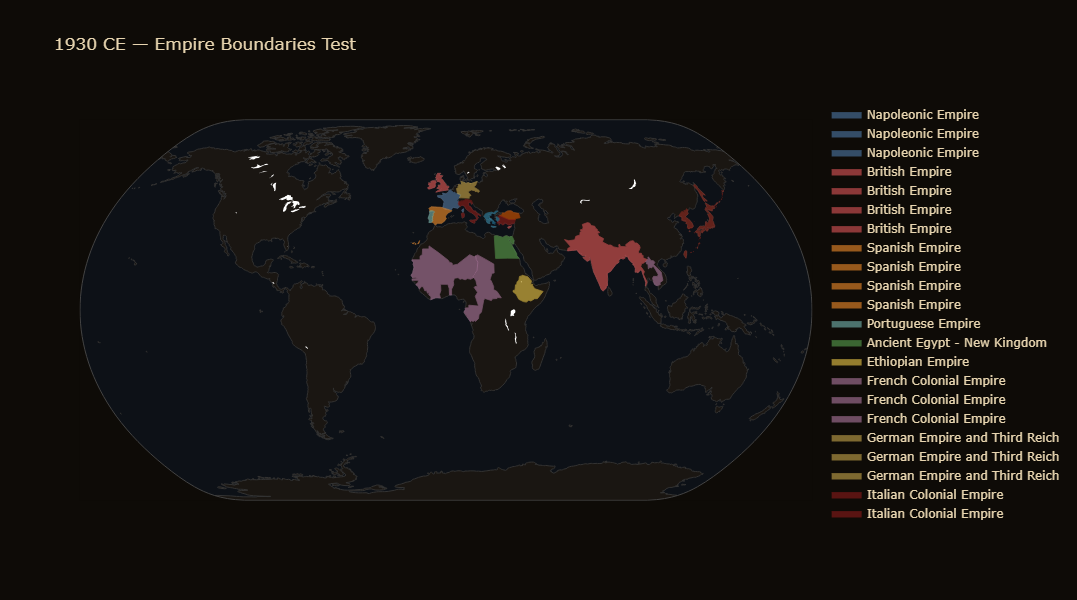

Total traces built: 108


In [9]:
import geopandas as gpd
import plotly.graph_objects as go
import json
import os
import pandas as pd

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

reverse_master = {}
for civ_name, repo_names in mapping.items():
    if not repo_names:
        continue
    for rn in repo_names:
        if rn not in reverse_master:
            reverse_master[rn] = civ_name

all_repo_names = set(reverse_master.keys())

# Load 1930 snapshot
gdf = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1930.geojson"))
empire_gdf = gdf[gdf['NAME'].isin(all_repo_names)].copy()

COLOURS = {
    'Napoleonic Empire':             '#4E79A7',
    'British Empire':                '#E15759',
    'Spanish Empire':                '#F28E2B',
    'Portuguese Empire':             '#76B7B2',
    'Ancient Egypt - New Kingdom':   '#59A14F',
    'Ethiopian Empire':              '#EDC948',
    'French Colonial Empire':        '#B07AA1',
    'German Empire and Third Reich': '#C9A84C',
    'Italian Colonial Empire':       '#8B1A1A',
    'Classical Greece':              '#2E86AB',
    'Ottoman Empire':                '#D35400',
    'Empire of Japan':               '#922B21',
}

traces = []
for _, row in empire_gdf.iterrows():
    civ_name = reverse_master.get(row['NAME'], '?')
    colour   = COLOURS.get(civ_name, '#888888')
    geom     = row.geometry

    if geom is None or geom.is_empty:
        continue

    geom = geom.simplify(0.3, preserve_topology=True)

    polygons = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]

    for poly in polygons:
        if poly.is_empty:
            continue
        coords = list(poly.exterior.coords)
        if len(coords) < 3:
            continue
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        if lons[0] != lons[-1]:
            lons.append(lons[0])
            lats.append(lats[0])

        traces.append(go.Scattergeo(
            lon=lons, lat=lats,
            mode='lines',
            fill='toself',
            fillcolor=colour,
            opacity=0.6,
            line=dict(color=colour, width=0.8),
            name=civ_name,
            hoverinfo='name',
            showlegend=True,
        ))

fig = go.Figure(data=traces)
fig.update_geos(
    showland=True, landcolor='#1a1612',
    showocean=True, oceancolor='#0d1117',
    showcoastlines=True, coastlinecolor='#333',
    projection_type='natural earth',
    bgcolor='#0e0b07'
)
fig.update_layout(
    paper_bgcolor='#0e0b07',
    font_color='#e8d5b0',
    height=600,
    title='1930 CE — Empire Boundaries Test'
)
fig.show()
print(f"Total traces built: {len(traces)}")

In [15]:
import geopandas as gpd
import json
import pandas as pd
import numpy as np
import os

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"
CIVS_FILE    = "../data/processed/civilisations_clean.csv"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

# Load and clean ALL numeric columns upfront
civs_df = pd.read_csv(CIVS_FILE)
for col in civs_df.columns:
    if 'year' in col.lower():
        civs_df[col] = pd.to_numeric(civs_df[col], errors='coerce').fillna(0).astype(int)

meta_dict = {row['name']: row.to_dict() for _, row in civs_df.iterrows()}

reverse_master = {}
for civ_name, repo_names in mapping.items():
    if not repo_names:
        continue
    for rn in repo_names:
        if rn not in reverse_master:
            reverse_master[rn] = civ_name

all_repo_names = set(reverse_master.keys())
known_civs     = set(civs_df['name'].tolist())
all_mapped     = set(reverse_master.values())
unknown_civs   = all_mapped - known_civs

year = 1938

known_active = set(
    civs_df[
        (civs_df['founded_year'] <= year) &
        (civs_df['collapse_end_year'] >= year)
    ]['name'].tolist()
)
active_civs = known_active | unknown_civs

gdf = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1938.geojson"))

print(f"Known active: {sorted(known_active)}")
print(f"\nAll 1938 feature names:")
for name in sorted(gdf['NAME'].dropna().unique()):
    in_mapping  = name in all_repo_names
    mapped_to   = reverse_master.get(name, '—')
    print(f"  {'✓' if in_mapping else '·'} {name:<50} → {mapped_to}")

Known active: ['British Empire', 'Empire of Japan', 'French Colonial Empire', 'German Empire and Third Reich', 'Italian Colonial Empire', 'Portuguese Empire', 'Russian Empire and USSR']

All 1938 feature names:
  · Afghanistan                                        → —
  · Albania                                            → —
  · Algeria (France)                                   → —
  · American Samoa                                     → —
  · Andorra                                            → —
  · Angola (Portugal)                                  → —
  · Anguilla                                           → —
  · Antigua and Barbuda                                → —
  · Argentina                                          → —
  · Armenia                                            → —
  · Australia                                          → —
  · Bahamas                                            → —
  · Barbados                                           → —
  · Belgian Congo     

In [16]:
import json

MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

# Add missing name variants
mapping['British Empire'].append('United Kingdom')

# Fix problematic mappings that match modern countries to ancient civs
# Remove generic country names that bleed across eras
# Spain → Spanish Empire: Spain the country exists post-1898 as a nation
# We handle this in the pipeline by checking active years

with open(MAPPING_FILE, 'w') as f:
    json.dump(mapping, f, indent=2)

print("Updated mapping. British Empire now includes:")
print(mapping['British Empire'])

Updated mapping. British Empire now includes:
['United Kingdom of Great Britain and Ireland', 'British Raj', 'British East Africa', 'United Kingdom']


Active civs: ['British Empire', 'Empire of Japan', 'French Colonial Empire', 'German Empire and Third Reich', 'Italian Colonial Empire', 'Portuguese Empire', 'Russian Empire and USSR']
  United Kingdom → British Empire: 4 polygons added
  Portugal → Portuguese Empire: 1 polygons added
  French Indo-China → French Colonial Empire: 1 polygons added
  French West Africa → French Colonial Empire: 1 polygons added
  French Equatorial Africa → French Colonial Empire: 2 polygons added
  Germany → German Empire and Third Reich: 2 polygons added
  Italy → Italian Colonial Empire: 8 polygons added
  British Raj → British Empire: 1 polygons added
  USSR → Russian Empire and USSR: 3 polygons added
  Italy → Italian Colonial Empire: 4 polygons added
  Empire of Japan → Empire of Japan: 62 polygons added

Total traces: 89


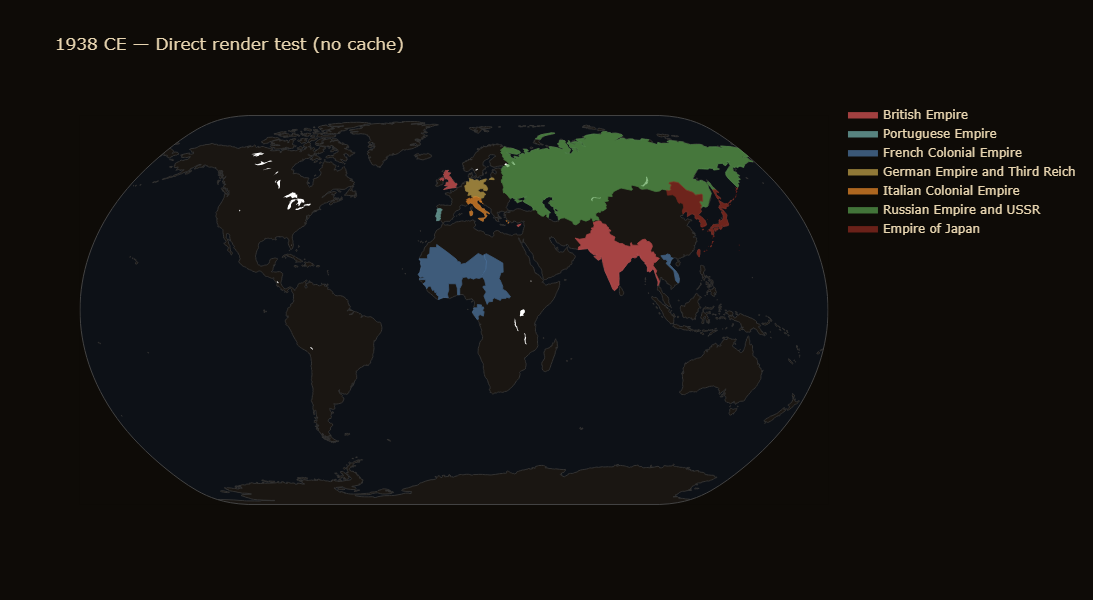

In [18]:
import geopandas as gpd
import plotly.graph_objects as go
import json
import pandas as pd
import numpy as np
import os

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"
CIVS_FILE    = "../data/processed/civilisations_clean.csv"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

civs_df = pd.read_csv(CIVS_FILE)
for col in civs_df.columns:
    if 'year' in col.lower():
        civs_df[col] = pd.to_numeric(civs_df[col], errors='coerce').fillna(0).astype(int)

meta_dict = {row['name']: row.to_dict() for _, row in civs_df.iterrows()}

reverse_master = {}
for civ_name, repo_names in mapping.items():
    if not repo_names:
        continue
    for rn in repo_names:
        if rn not in reverse_master:
            reverse_master[rn] = civ_name

all_repo_names = set(reverse_master.keys())

COLOURS = {
    'British Empire':                '#E15759',
    'French Colonial Empire':        '#4E79A7',
    'German Empire and Third Reich': '#C9A84C',
    'Italian Colonial Empire':       '#F28E2B',
    'Empire of Japan':               '#922B21',
    'Russian Empire and USSR':       '#59A14F',
    'Portuguese Empire':             '#76B7B2',
    'Spanish Empire':                '#B07AA1',
}

year = 1938
known_active = set(
    civs_df[
        (civs_df['founded_year'] <= year) &
        (civs_df['collapse_end_year'] >= year)
    ]['name'].tolist()
)
print(f"Active civs: {sorted(known_active)}")

gdf        = gpd.read_file(os.path.join(BASEMAP_PATH, "world_1938.geojson"))
empire_gdf = gdf[gdf['NAME'].isin(all_repo_names)].copy()

traces = []
shown  = set()

for _, row in empire_gdf.iterrows():
    repo_name = row['NAME']
    civ_name  = reverse_master.get(repo_name)
    if not civ_name or civ_name not in known_active:
        continue

    colour = COLOURS.get(civ_name, '#888888')
    geom   = row.geometry
    if geom is None or geom.is_empty:
        continue

    geom = geom.simplify(0.3, preserve_topology=True)
    polys = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]

    poly_count = 0
    for poly in polys:
        if poly.is_empty:
            continue
        coords = list(poly.exterior.coords)
        if len(coords) < 3:
            continue
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        if lons[0] != lons[-1]:
            lons.append(lons[0])
            lats.append(lats[0])

        traces.append(go.Scattergeo(
            lon=lons, lat=lats,
            mode='lines',
            fill='toself',
            fillcolor=colour,
            opacity=0.7,
            line=dict(color=colour, width=0.8),
            name=civ_name,
            hoverinfo='name',
            showlegend=(civ_name not in shown),
        ))
        shown.add(civ_name)
        poly_count += 1

    print(f"  {repo_name} → {civ_name}: {poly_count} polygons added")

print(f"\nTotal traces: {len(traces)}")

fig = go.Figure(data=traces)
fig.update_geos(
    showland=True,  landcolor='#1a1612',
    showocean=True, oceancolor='#0d1117',
    showcoastlines=True, coastlinecolor='#333',
    projection_type='natural earth',
    bgcolor='#0e0b07'
)
fig.update_layout(
    paper_bgcolor='#0e0b07',
    font_color='#e8d5b0',
    height=600,
    title='1938 CE — Direct render test (no cache)'
)
fig.show()

In [19]:
import geopandas as gpd
import json
import pandas as pd
import os

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"
CIVS_FILE    = "../data/processed/civilisations_clean.csv"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

civs_df = pd.read_csv(CIVS_FILE)
for col in civs_df.columns:
    if 'year' in col.lower():
        civs_df[col] = pd.to_numeric(civs_df[col], errors='coerce').fillna(0).astype(int)

# Build reverse: repo_name → civ_name
reverse_master = {}
for civ_name, repo_names in mapping.items():
    if not repo_names:
        continue
    for rn in repo_names:
        if rn not in reverse_master:
            reverse_master[rn] = civ_name

# For each civ, get its lifespan
civ_lifespan = {
    row['name']: (int(row['founded_year']), int(row['collapse_end_year']))
    for _, row in civs_df.iterrows()
}

# Load all snapshots and check for bleeds
snapshot_files = sorted([
    f for f in os.listdir(BASEMAP_PATH)
    if f.startswith('world_') and f.endswith('.geojson')
])

print("=== MAPPING ACCURACY AUDIT ===")
print("Showing cases where a repo name appears in a snapshot")
print("OUTSIDE the mapped civilisation's lifespan\n")

problems = []

for fname in snapshot_files:
    year_str = fname.replace('world_','').replace('.geojson','')
    year = -int(year_str.replace('bc','')) if year_str.startswith('bc') else int(year_str)
    if not (-3100 <= year <= 2010):
        continue

    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    empire_features = gdf[gdf['NAME'].isin(reverse_master.keys())].copy()

    for _, row in empire_features.iterrows():
        repo_name = row['NAME']
        civ_name  = reverse_master.get(repo_name)
        if not civ_name:
            continue

        lifespan = civ_lifespan.get(civ_name)
        if not lifespan:
            continue

        founded, collapsed = lifespan
        if year < founded or year > collapsed:
            problems.append({
                'snapshot_year': year,
                'repo_name': repo_name,
                'civ_name': civ_name,
                'civ_founded': founded,
                'civ_collapsed': collapsed,
                'years_outside': min(abs(year - founded), abs(year - collapsed))
            })

problems_df = pd.DataFrame(problems)

if problems_df.empty:
    print("No mapping accuracy issues found.")
else:
    # Group by repo_name and civ_name to show the range of problem years
    summary = (problems_df
               .groupby(['repo_name', 'civ_name', 'civ_founded', 'civ_collapsed'])
               .agg(
                   problem_years=('snapshot_year', list),
                   n_snapshots=('snapshot_year', 'count')
               )
               .reset_index()
               .sort_values('n_snapshots', ascending=False))

    print(f"Total problem instances: {len(problems_df)}")
    print(f"Unique repo_name/civ pairs with issues: {len(summary)}\n")

    for _, row in summary.iterrows():
        years = sorted(row['problem_years'])
        founded_str = f"{abs(row['civ_founded'])} {'BCE' if row['civ_founded'] < 0 else 'CE'}"
        collapsed_str = f"{abs(row['civ_collapsed'])} {'BCE' if row['civ_collapsed'] < 0 else 'CE'}"
        print(f"PROBLEM: '{row['repo_name']}' → '{row['civ_name']}'")
        print(f"  Civ lifespan: {founded_str} to {collapsed_str}")
        print(f"  Appears wrongly in {row['n_snapshots']} snapshots: {years}")
        print()

=== MAPPING ACCURACY AUDIT ===
Showing cases where a repo name appears in a snapshot
OUTSIDE the mapped civilisation's lifespan

Total problem instances: 161
Unique repo_name/civ pairs with issues: 37

PROBLEM: 'France' → 'Napoleonic Empire'
  Civ lifespan: 1804 CE to 1815 CE
  Appears wrongly in 25 snapshots: [1279, 1300, 1400, 1492, 1500, 1530, 1600, 1650, 1700, 1715, 1783, 1800, 1880, 1880, 1900, 1900, 1914, 1920, 1930, 1938, 1945, 1960, 1994, 2000, 2010]

PROBLEM: 'Egypt' → 'Ancient Egypt - New Kingdom'
  Civ lifespan: 1550 BCE to 1069 BCE
  Appears wrongly in 18 snapshots: [-3000, -2000, -1000, -700, 1715, 1815, 1880, 1900, 1900, 1914, 1920, 1930, 1938, 1945, 1960, 1994, 2000, 2010]

PROBLEM: 'Italy' → 'Italian Colonial Empire'
  Civ lifespan: 1882 CE to 1947 CE
  Appears wrongly in 12 snapshots: [1880, 1960, 1960, 1994, 1994, 1994, 2000, 2000, 2000, 2010, 2010, 2010]

PROBLEM: 'Greece' → 'Classical Greece'
  Civ lifespan: 800 BCE to 146 BCE
  Appears wrongly in 11 snapshots: [188

In [20]:
import json

MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

# Year-range aware mapping
# Format: each repo name gets a (from_year, to_year) range
# Only match the repo name if snapshot_year falls within this range
# None = no limit on that side

CORRECTED_MAPPING = {
    "Sumerian City-States":          [("city-states", -3100, -2100), ("Ur", -3100, -2100)],
    "Akkadian Empire":               [("city-states", -2400, -2000), ("Ur", -2400, -2000)],
    "Neo-Babylonian Empire":         [("Babylonia", -700, -500)],
    "Achaemenid Persian Empire":     [("Achaemenid Empire", -600, -300)],
    "Sassanid Empire":               [("Sasanian Empire", 200, 660), ("Sasanian dependencies", 200, 660)],
    "Ancient Egypt - New Kingdom":   [("Egypt", -1600, -1000)],
    "Classical Greece":              [("Greek city-states", -900, -100), ("Greece", -900, -100)],
    "Macedonian Empire":             [("Empire of Alexander", -340, -280), ("Macedon and Hellenic League", -340, -180)],
    "Roman Empire":                  [("Roman Empire", -100, 500), ("Rome", -100, 100), ("Western Roman Empire", 300, 500)],
    "Byzantine Empire":              [("Byzantine Empire", 300, 1500), ("Eastern Roman Empire", 300, 800)],
    "Parthian Empire":               [("Parthian Empire", -300, 250), ("Parthia", -300, 100)],
    "Umayyad Caliphate":             [("Umayyad Caliphate", 650, 760)],
    "Abbasid Caliphate":             [("Abbasid Caliphate", 740, 1270)],
    "Ottoman Empire":                [("Ottoman Empire", 1290, 1923), ("Ottoman Sultanate", 1900, 1923)],
    "Maurya Empire":                 [("Mauryan Empire", -330, -180)],
    "Gupta Empire":                  [("Gupta Empire", 310, 560)],
    "Mughal Empire":                 [("Mughal Empire", 1520, 1870)],
    "Qin Dynasty":                   [("Qin", -230, -200)],
    "Han Dynasty":                   [("Han", -210, 230), ("Han Empire", -210, 50)],
    "Tang Dynasty":                  [("Tang Empire", 610, 920)],
    "Song Dynasty":                  [("Song Empire", 950, 1290)],
    "Yuan Dynasty":                  [("Mongol Empire", 1260, 1380)],
    "Ming Dynasty":                  [("Ming Chinese Empire", 1360, 1650), ("Ming Empire", 1360, 1650)],
    "Qing Dynasty":                  [("Qing Empire", 1640, 1920), ("Manchu Empire", 1640, 1920)],
    "Mongol Empire":                 [("Mongol Empire", 1200, 1270)],
    "Timurid Empire":                [("Timurid Empire", 1360, 1520), ("Timurid Emirates", 1360, 1520)],
    "Kingdom of Kush":               [("Kush", -1200, -400), ("Meroe", -600, 380)],
    "Kingdom of Aksum":              [("Axum", 50, 960)],
    "Mali Empire":                   [("Mali", 1230, 1680)],
    "Classic Maya":                  [("Maya chiefdoms and states", 200, 950), ("Maya city-states", 200, 950)],
    "Teotihuacan":                   [("Teotihuacán", -50, 780), ("Teotihuacàn", -50, 780)],
    "Aztec Empire":                  [("Aztec Empire", 1340, 1530), ("Mexihcah (Triple Alliance)", 1340, 1530)],
    "Inca Empire":                   [("Inca Empire", 1430, 1540)],
    "Carolingian Empire":            [("Carolingian Empire", 790, 900), ("Frankish Kingdom", 600, 810)],
    "Holy Roman Empire":             [("Holy Roman Empire", 960, 1810)],
    "Spanish Empire":                [("Spain", 1490, 1900), ("Vice Royalty of New Spain", 1490, 1830), ("Vice-Royalty of Peru", 1490, 1830)],
    "Napoleonic Empire":             [("France", 1803, 1816)],
    "Austro-Hungarian Empire":       [("Austro-Hungarian Empire", 1860, 1920), ("Austria Hungary", 1860, 1920), ("Austrian Empire", 1804, 1868)],
    "German Empire and Third Reich": [("German Empire", 1860, 1920), ("Germany", 1860, 1950)],
    "Italian Colonial Empire":       [("Italy", 1880, 1950)],
    "Empire of Japan":               [("Empire of Japan", 1860, 1950), ("Imperial Japan", 1860, 1950)],
    "French Colonial Empire":        [("France", 1534, 1803), ("France", 1816, 1962), ("French Indo-China", 1880, 1960), ("French West Africa", 1880, 1960), ("French Equatorial Africa", 1880, 1960)],
    "British Empire":                [("United Kingdom of Great Britain and Ireland", 1800, 1940), ("United Kingdom", 1800, 1998), ("British Raj", 1850, 1950), ("British East Africa", 1880, 1965)],
    "Russian Empire and USSR":       [("Russian Empire", 1540, 1920), ("USSR", 1920, 1992), ("Russia", 1540, 1992)],
    "Portuguese Empire":             [("Portugal", 1414, 2000)],
    # Tier 1
    "Hittite Empire":                [("Hittites", -1700, -1100)],
    "Mycenaean Greece":              [("Greek city-states", -1700, -1100)],
    "Carthage":                      [("Carthaginian Empire", -900, -140), ("Carthage", -900, -140)],
    "Seleucid Empire":               [("Seleucid Kingdom", -320, -50)],
    "Lydian Kingdom":                [],
    "Shang Dynasty":                 [("Xia", -1650, -1000)],
    "Zhou Dynasty":                  [("Zhou states", -550, -200), ("Zhoa", -1100, -700)],
    "Sui Dynasty":                   [("Sui Empire", 575, 625)],
    "Khmer Empire":                  [("Khmer Empire", 790, 1440)],
    "Srivijaya Empire":              [("Srivijaya Empire", 640, 1290)],
    "Vijayanagara Empire":           [("Vijayanagara", 1330, 1660)],
    "Songhai Empire":                [("Songhai", 1460, 1600)],
    "Great Zimbabwe":                [("Great Zimbabwe", 1090, 1460)],
    "Xiongnu Confederation":         [("Xiongnu", -220, 50), ("Southern Xiongnu", 0, 110)],
    "Golden Horde":                  [("Golden Horde", 1240, 1510), ("Khanate of the Golden Horde", 1240, 1510)],
    "Kievan Rus":                    [("Kievan Rus", 875, 1250), ("Kyivan Rus", 875, 1250)],
    "Kingdom of France":             [("Kingdom of France", 980, 1300), ("France", 1300, 1804)],
    "Republic of Venice":            [("Venice", 690, 1800)],
    # South Asia
    "Indus Valley Civilisation":     [("Indus valley civilization", -2700, -1850)],
    "Kushan Empire":                 [("Kushan Empire", -50, 390)],
    "Chola Dynasty":                 [("Chola state", 840, 1300), ("Chola", 840, 1300), ("Cholas", 840, 1300)],
    "Delhi Sultanate":               [("Sultanate of Delhi", 1200, 1530)],
    "Maratha Empire":                [("Maratha", 1670, 1820), ("Maratha Confederacy", 1670, 1820)],
    # Africa
    "Ghana Empire":                  [("Empire of Ghana", 690, 1250)],
    "Kanem-Bornu Empire":            [("Kanem", 790, 1250), ("Bornu-Kanem", 1250, 1900), ("Kanem-Bornu", 1800, 1910)],
    "Kingdom of Kongo":              [("Congo", 1385, 1920)],
    "Mutapa Empire":                 [("Mwenemutapa", 1420, 1770), ("Great Zimbabwe", 1090, 1460)],
    "Ethiopian Empire":              [("Ethiopia", 1260, 1980), ("Abyssinia", 1260, 1980)],
    "Sokoto Caliphate":              [("Sokoto Caliphate", 1800, 1910)],
    "Kingdom of Benin":              [("Benin", 1175, 1900)],
    "Kilwa Sultanate":               [("Islamic city-states", 890, 1520)],
    "Asante Empire":                 [("Asante", 1695, 1910)],
}

# Save as new format
with open(MAPPING_FILE, 'w') as f:
    json.dump(CORRECTED_MAPPING, f, indent=2)

print(f"Saved {len(CORRECTED_MAPPING)} civilisation mappings")
print("Format: [repo_name, from_year, to_year]")

# Quick validation — count total repo entries
total = sum(len(v) for v in CORRECTED_MAPPING.values())
print(f"Total repo name entries: {total}")

Saved 77 civilisation mappings
Format: [repo_name, from_year, to_year]
Total repo name entries: 123


In [24]:
import geopandas as gpd
import json
import pandas as pd
import os

BASEMAP_PATH = "../data/geospatial/historical-basemaps/geojson"
MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"
CIVS_FILE    = "../data/processed/civilisations_clean.csv"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

civs_df = pd.read_csv(CIVS_FILE)
for col in civs_df.columns:
    if 'year' in col.lower():
        civs_df[col] = pd.to_numeric(civs_df[col], errors='coerce').fillna(0).astype(int)

# Lifespan per civilisation from dataset
civ_lifespan = {
    row['name']: (int(row['founded_year']), int(row['collapse_end_year']))
    for _, row in civs_df.iterrows()
}

# Load all snapshot files
snapshot_files = sorted([
    f for f in os.listdir(BASEMAP_PATH)
    if f.startswith('world_') and f.endswith('.geojson')
])

problems = []

for fname in snapshot_files:
    year_str = fname.replace('world_','').replace('.geojson','')
    year = -int(year_str.replace('bc','')) if year_str.startswith('bc') else int(year_str)
    if not (-3100 <= year <= 2010):
        continue

    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    gdf_names = set(gdf['NAME'].dropna().unique())

    for civ_name, entries in mapping.items():
        if not entries:
            continue
        lifespan = civ_lifespan.get(civ_name)
        if not lifespan:
            continue
        founded, collapsed = lifespan

        for entry in entries:
            if isinstance(entry, list) and len(entry) == 3:
                rn, from_y, to_y = entry
            else:
                continue

            if rn not in gdf_names:
                continue

            outside_mapping  = year < from_y or year > to_y
            outside_lifespan = year < founded or year > collapsed

            if outside_mapping or outside_lifespan:
                problems.append({
                    'snapshot_year': year,
                    'repo_name':     rn,
                    'civ_name':      civ_name,
                    'civ_founded':   founded,
                    'civ_collapsed': collapsed,
                    'mapping_from':  from_y,
                    'mapping_to':    to_y,
                })

problems_df = pd.DataFrame(problems)

if problems_df.empty:
    print("✓ No mapping accuracy issues found.")
else:
    summary = (problems_df
               .groupby(['repo_name', 'civ_name', 'civ_founded',
                         'civ_collapsed', 'mapping_from', 'mapping_to'])
               .agg(problem_years=('snapshot_year', list),
                    n_snapshots=('snapshot_year', 'count'))
               .reset_index()
               .sort_values('n_snapshots', ascending=False))

    print(f"Total problem instances: {len(problems_df)}")
    print(f"Unique pairs with issues: {len(summary)}\n")

    for _, row in summary.iterrows():
        years = sorted(row['problem_years'])
        f_str = f"{abs(row['civ_founded'])} {'BCE' if row['civ_founded']<0 else 'CE'}"
        c_str = f"{abs(row['civ_collapsed'])} {'BCE' if row['civ_collapsed']<0 else 'CE'}"
        m_str = f"{row['mapping_from']} → {row['mapping_to']}"
        print(f"PROBLEM: '{row['repo_name']}' → '{row['civ_name']}'")
        print(f"  Civ lifespan:   {f_str} to {c_str}")
        print(f"  Mapping range:  {m_str}")
        print(f"  Wrong in {row['n_snapshots']} snapshots: {years}")
        print()

Total problem instances: 187
Unique pairs with issues: 43

PROBLEM: 'France' → 'Napoleonic Empire'
  Civ lifespan:   1804 CE to 1815 CE
  Mapping range:  1804 → 1815
  Wrong in 23 snapshots: [1279, 1300, 1400, 1492, 1500, 1530, 1600, 1650, 1700, 1715, 1783, 1800, 1880, 1900, 1914, 1920, 1930, 1938, 1945, 1960, 1994, 2000, 2010]

PROBLEM: 'France' → 'French Colonial Empire'
  Civ lifespan:   1534 CE to 1980 CE
  Mapping range:  1534 → 1804
  Wrong in 18 snapshots: [1279, 1300, 1400, 1492, 1500, 1530, 1815, 1880, 1900, 1914, 1920, 1930, 1938, 1945, 1960, 1994, 2000, 2010]

PROBLEM: 'Egypt' → 'Ancient Egypt - New Kingdom'
  Civ lifespan:   1550 BCE to 1069 BCE
  Mapping range:  -1550 → -1069
  Wrong in 17 snapshots: [-3000, -2000, -1000, -700, 1715, 1815, 1880, 1900, 1914, 1920, 1930, 1938, 1945, 1960, 1994, 2000, 2010]

PROBLEM: 'France' → 'French Colonial Empire'
  Civ lifespan:   1534 CE to 1980 CE
  Mapping range:  1815 → 1962
  Wrong in 15 snapshots: [1279, 1300, 1400, 1492, 1500, 15

In [23]:
import json

MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

CORRECTED_MAPPING = {
    "Sumerian City-States":          [["city-states", -3100, -2200], ["Ur", -3100, -2200]],
    "Akkadian Empire":               [["city-states", -2334, -2154], ["Ur", -2334, -2154]],
    "Neo-Babylonian Empire":         [["Babylonia", -626, -539]],
    "Achaemenid Persian Empire":     [["Achaemenid Empire", -550, -330]],
    "Sassanid Empire":               [["Sasanian Empire", 224, 651], ["Sasanian dependencies", 224, 651]],
    "Ancient Egypt - New Kingdom":   [["Egypt", -1550, -1069]],
    "Classical Greece":              [["Greek city-states", -800, -146], ["Greece", -800, -146]],
    "Macedonian Empire":             [["Empire of Alexander", -336, -301], ["Macedon and Hellenic League", -336, -301]],
    "Roman Empire":                  [["Roman Empire", -27, 476], ["Rome", -27, 100], ["Western Roman Empire", 285, 476]],
    "Byzantine Empire":              [["Byzantine Empire", 330, 1453], ["Eastern Roman Empire", 330, 476]],
    "Parthian Empire":               [["Parthian Empire", -247, 224], ["Parthia", -247, 100]],
    "Umayyad Caliphate":             [["Umayyad Caliphate", 661, 750]],
    "Abbasid Caliphate":             [["Abbasid Caliphate", 750, 1258]],
    "Ottoman Empire":                [["Ottoman Empire", 1299, 1922], ["Ottoman Sultanate", 1908, 1922]],
    "Maurya Empire":                 [["Mauryan Empire", -322, -185]],
    "Gupta Empire":                  [["Gupta Empire", 320, 550]],
    "Mughal Empire":                 [["Mughal Empire", 1526, 1857]],
    "Qin Dynasty":                   [["Qin", -221, -206]],
    "Han Dynasty":                   [["Han", -206, 220], ["Han Empire", -206, 1]],
    "Tang Dynasty":                  [["Tang Empire", 618, 907]],
    "Song Dynasty":                  [["Song Empire", 960, 1279]],
    "Yuan Dynasty":                  [["Mongol Empire", 1271, 1368]],
    "Ming Dynasty":                  [["Ming Chinese Empire", 1368, 1644], ["Ming Empire", 1368, 1644]],
    "Qing Dynasty":                  [["Qing Empire", 1644, 1912], ["Manchu Empire", 1644, 1912]],
    "Mongol Empire":                 [["Mongol Empire", 1206, 1260]],
    "Timurid Empire":                [["Timurid Empire", 1370, 1507], ["Timurid Emirates", 1370, 1507]],
    "Kingdom of Kush":               [["Kush", -1070, -400], ["Meroe", -300, 350]],
    "Kingdom of Aksum":              [["Axum", 100, 940]],
    "Mali Empire":                   [["Mali", 1235, 1670]],
    "Classic Maya":                  [["Maya chiefdoms and states", 250, 900], ["Maya city-states", 250, 900]],
    "Teotihuacan":                   [["Teotihuacán", -100, 750], ["Teotihuacàn", -100, 750]],
    "Aztec Empire":                  [["Aztec Empire", 1345, 1521], ["Mexihcah (Triple Alliance)", 1345, 1521]],
    "Inca Empire":                   [["Inca Empire", 1438, 1533]],
    "Carolingian Empire":            [["Carolingian Empire", 800, 888], ["Frankish Kingdom", 750, 800]],
    "Holy Roman Empire":             [["Holy Roman Empire", 962, 1806]],
    "Spanish Empire":                [["Spain", 1492, 1898], ["Vice Royalty of New Spain", 1492, 1821], ["Vice-Royalty of Peru", 1492, 1824]],
    "Napoleonic Empire":             [["France", 1804, 1815]],
    "Austro-Hungarian Empire":       [["Austro-Hungarian Empire", 1867, 1918], ["Austria Hungary", 1867, 1918], ["Austrian Empire", 1804, 1867]],
    "German Empire and Third Reich": [["German Empire", 1871, 1918], ["Germany", 1871, 1945]],
    "Italian Colonial Empire":       [["Italy", 1882, 1947]],
    "Empire of Japan":               [["Empire of Japan", 1868, 1947], ["Imperial Japan", 1868, 1947]],
    "French Colonial Empire":        [["France", 1534, 1804], ["France", 1815, 1962], ["French Indo-China", 1858, 1954], ["French West Africa", 1890, 1960], ["French Equatorial Africa", 1910, 1960]],
    "British Empire":                [["United Kingdom of Great Britain and Ireland", 1801, 1922], ["United Kingdom", 1922, 1997], ["British Raj", 1858, 1947], ["British East Africa", 1895, 1963]],
    "Russian Empire and USSR":       [["Russian Empire", 1547, 1917], ["USSR", 1922, 1991]],
    "Portuguese Empire":             [["Portugal", 1415, 1999]],
    "Hittite Empire":                [["Hittites", -1650, -1180]],
    "Mycenaean Greece":              [["Greek city-states", -1600, -1100]],
    "Carthage":                      [["Carthaginian Empire", -814, -146], ["Carthage", -814, -146]],
    "Seleucid Empire":               [["Seleucid Kingdom", -312, -63]],
    "Lydian Kingdom":                [],
    "Shang Dynasty":                 [["Xia", -1600, -1046]],
    "Zhou Dynasty":                  [["Zhou states", -500, -256], ["Zhoa", -1046, -700]],
    "Sui Dynasty":                   [["Sui Empire", 581, 618]],
    "Khmer Empire":                  [["Khmer Empire", 802, 1431]],
    "Srivijaya Empire":              [["Srivijaya Empire", 650, 1275]],
    "Vijayanagara Empire":           [["Vijayanagara", 1336, 1646]],
    "Songhai Empire":                [["Songhai", 1464, 1591]],
    "Great Zimbabwe":                [["Great Zimbabwe", 1100, 1450]],
    "Xiongnu Confederation":         [["Xiongnu", -209, 50], ["Southern Xiongnu", 0, 93]],
    "Golden Horde":                  [["Golden Horde", 1242, 1502], ["Khanate of the Golden Horde", 1242, 1502]],
    "Kievan Rus":                    [["Kievan Rus", 882, 1240], ["Kyivan Rus", 882, 1240]],
    "Kingdom of France":             [["Kingdom of France", 987, 1300], ["France", 1300, 1804]],
    "Republic of Venice":            [["Venice", 697, 1797]],
    "Indus Valley Civilisation":     [["Indus valley civilization", -2600, -1900]],
    "Kushan Empire":                 [["Kushan Empire", 30, 375]],
    "Chola Dynasty":                 [["Chola state", 848, 1279], ["Chola", 848, 1279], ["Cholas", 848, 1279]],
    "Delhi Sultanate":               [["Sultanate of Delhi", 1206, 1526]],
    "Maratha Empire":                [["Maratha", 1674, 1818], ["Maratha Confederacy", 1674, 1818]],
    "Ghana Empire":                  [["Empire of Ghana", 700, 1240]],
    "Kanem-Bornu Empire":            [["Kanem", 700, 1250], ["Bornu-Kanem", 1250, 1846], ["Kanem-Bornu", 1846, 1900]],
    "Kingdom of Kongo":              [["Congo", 1390, 1914]],
    "Mutapa Empire":                 [["Mwenemutapa", 1430, 1760], ["Great Zimbabwe", 1100, 1450]],
    "Ethiopian Empire":              [["Ethiopia", 1270, 1974], ["Abyssinia", 1270, 1936]],
    "Sokoto Caliphate":              [["Sokoto Caliphate", 1804, 1903]],
    "Kingdom of Benin":              [["Benin", 1180, 1897]],
    "Kilwa Sultanate":               [["Islamic city-states", 900, 1513]],
    "Asante Empire":                 [["Asante", 1701, 1902]],
}

with open(MAPPING_FILE, 'w') as f:
    json.dump(CORRECTED_MAPPING, f, indent=2)

print(f"Saved {len(CORRECTED_MAPPING)} civilisations")
total = sum(len(v) for v in CORRECTED_MAPPING.values())
print(f"Total repo entries: {total}")
print("Done — rerun audit to verify")

Saved 77 civilisations
Total repo entries: 122
Done — rerun audit to verify


In [29]:
# Only flag if snapshot year is within mapping range BUT outside civ lifespan
# OR if snapshot year is within civ lifespan BUT outside mapping range
# The first case = empire shown when it shouldn't exist
# The second case = empire missing when it should show

problems = []

for fname in snapshot_files:
    year_str = fname.replace('world_','').replace('.geojson','')
    year = -int(year_str.replace('bc','')) if year_str.startswith('bc') else int(year_str)
    if not (-3100 <= year <= 2010):
        continue

    gdf = gpd.read_file(os.path.join(BASEMAP_PATH, fname))
    gdf_names = set(gdf['NAME'].dropna().unique())

    for civ_name, entries in mapping.items():
        if not entries:
            continue
        lifespan = civ_lifespan.get(civ_name)
        if not lifespan:
            continue
        founded, collapsed = lifespan

        for entry in entries:
            if not (isinstance(entry, list) and len(entry) == 3):
                continue
            rn, from_y, to_y = entry

            if rn not in gdf_names:
                continue

            # REAL BUG: repo name in snapshot AND within mapping range
            # BUT outside civ lifespan = empire shows when it shouldn't exist
            in_mapping_range  = from_y <= year <= to_y
            in_civ_lifespan   = founded <= year <= collapsed

            if in_mapping_range and not in_civ_lifespan:
                problems.append({
                    'type': 'GHOST — shows outside lifespan',
                    'snapshot_year': year,
                    'repo_name': rn,
                    'civ_name': civ_name,
                    'civ_founded': founded,
                    'civ_collapsed': collapsed,
                    'mapping_from': from_y,
                    'mapping_to': to_y,
                })

if not problems:
    print("✓ Zero ghost empires — mapping is clean.")
else:
    df = pd.DataFrame(problems)
    for _, row in df.sort_values('n_snapshots' if 'n_snapshots' in df else 'snapshot_year',
                                  ascending=False).iterrows():
        print(f"GHOST: '{row['repo_name']}' → '{row['civ_name']}'")
        print(f"  Shows at {row['snapshot_year']} but civ only exists "
              f"{abs(row['civ_founded'])} {'BCE' if row['civ_founded']<0 else 'CE'} "
              f"– {abs(row['civ_collapsed'])} {'BCE' if row['civ_collapsed']<0 else 'CE'}")
        print(f"  Mapping range: {row['mapping_from']} → {row['mapping_to']}")
        print()

    print(f"Total ghost instances: {len(problems)}")

✓ Zero ghost empires — mapping is clean.


In [26]:
import json

MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

# Fix Austrian Empire range — end at 1866, not 1867
mapping["Austro-Hungarian Empire"] = [
    ["Austro-Hungarian Empire", 1867, 1918],
    ["Austria Hungary", 1867, 1918],
    ["Austrian Empire", 1815, 1866]
]

with open(MAPPING_FILE, 'w') as f:
    json.dump(mapping, f, indent=2)

print("Fixed. Rerun ghost audit to confirm.")

Fixed. Rerun ghost audit to confirm.


In [28]:
import json

MAPPING_FILE = "../data/geospatial/civilisation_mapping.json"

with open(MAPPING_FILE) as f:
    mapping = json.load(f)

mapping["Austro-Hungarian Empire"] = [
    ["Austro-Hungarian Empire", 1867, 1918],
    ["Austria Hungary", 1867, 1918],
    ["Austrian Empire", 1816, 1866]
]

with open(MAPPING_FILE, 'w') as f:
    json.dump(mapping, f, indent=2)

print("Fixed.")

Fixed.
